In [5]:
from collections import Counter
import json
from pathlib import Path
import random
import re
from typing import List


from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import textwrap

import evaluate

from langchain_core.documents import Document
from langchain_ollama import OllamaEmbeddings

from ollama import chat
from transformers import AutoTokenizer

from typing import Literal
from pydantic import BaseModel, Field

pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
with open('../data/articles.json', 'r', encoding='utf-8') as f:
    articles = json.load(f)
    
with open('../data/ground_truth.json', 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

with open('../data/questions.json', 'r', encoding='utf-8') as f:
    questions = json.load(f)

In [32]:
build_ollama_payload("Тест", max_tokens=50)

{'model': 'mistral:7b-instruct-v0.3-q4_K_M',
 'prompt': 'Тест',
 'stream': False,
 'options': {'temperature': 0.3, 'num_ctx': 128}}

1. Проверка на дубликатыы

In [5]:
print(f"Количество дубликатов в текстах: ", len(set([article['text'] for article in articles])) - len([article['text'] for article in articles]))
print(f"Количество дубликатов в топиках: ", len(set([article['title'] for article in articles])) - len([article['title'] for article in articles]))

Количество дубликатов в текстах:  0
Количество дубликатов в топиках:  0


2. Посмотрим на среднее и оценим разброс

In [6]:
length_text, length_topic = [], []
for article in articles:
    length_text.append(len(article['text']))
    length_topic.append(len(article['title']))

print(f'Средняя длина заголовка: {np.mean(length_topic):.1f}')
print(f"Средняя длина текста: {np.mean(length_text):.1f}")
pd.DataFrame({'Длина текстов': length_text,
              'Длина топика': length_topic,
              'Отклонение от средней длины текста': (length_text - np.mean(length_text)) * 100 / np.mean(length_text), 
              'Отклонение от среднего длины топика': (length_topic - np.mean(length_topic)) * 100 / np.mean(length_topic)
              })

Средняя длина заголовка: 47.6
Средняя длина текста: 784.8


,Длина текстов,Длина топика,Отклонение от средней длины текста,Отклонение от среднего длины топика
0,866,55,10.35,15.55
1,823,49,4.87,2.94
2,730,41,-6.98,-13.87
3,805,52,2.57,9.24
4,772,43,-1.63,-9.66
5,728,50,-7.24,5.04
6,785,55,0.03,15.55
7,767,55,-2.27,15.55
8,754,32,-3.92,-32.77
9,818,44,4.23,-7.56


3. Посмотрим на случайные документы. Проверим, есть ли артефакты или мусор в статье

In [7]:
for article in random.sample(articles, 5):
    print(article['title'])
    print(article['text'])
    print('=' * 80)

Руководство по управлению доступами и ролями
Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14 календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня admin требуют двойного согласования: руководителя функции и службы информационной безопасности. Ежеквартально владельцы систем обязаны проводить access review и подтверждать актуальность прав пользователей; неподтвержденные права блокируются через 5 рабочих дней после завершения кампании review. Для подрядчиков максимальный срок доступа ограничен датой контракта, но не более 90 дней без повторного согласования. Передача учетных данных третьим лицам запрещена и квалифицируется как грубое нарушение политики безопасности.
Положение о резервном копировании и восстановлении
Для всех продакшн-сервисов применяются политики резервного копирования по схеме 3-2-1

- Данные достаточно качественные, в них нет мусора, артефактов
- Топик по смыслу совпадает с текстом

4. Проверим распределение токенов

Средняя коли токена: 258.0
Максимальное количество токенов: 294


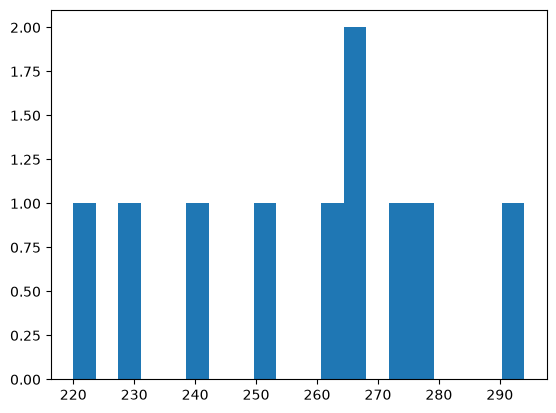

In [8]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen3-4b')

length_token = (
    [
        len(tokenizer.encode(article['text'], add_special_token=False)) 
        for article in articles
    ]
)

print(f'Средняя коли токена: {np.mean(length_token):.1f}')
print(f'Максимальное количество токенов: {max(length_token)}')
plt.hist(length_token, bins=20);

In [31]:
def answer_without_rag(question: str) -> str:
    response = chat(
        model='qwen3:4b-instruct',
        messages=[{
            "role": "system",
            "content": (
                "Отвечай на вопросы кратко и по существу. "
                "Если не знаешь ответа, ответь не знаю. "
                "Не выдумывай факты."
            )
        },                   
        {
            "role": "user",
            "content": question
        }        
        ],
        options={
            "temperature": 0
        },
        think=False
    )
    
    return response["message"]["content"]

Объединим вопросы и ответы в один список

In [27]:
index = {truth["id"]: truth for truth in ground_truth}

q_and_a = [
    {**question, **index[question["id"]]}
    for question in questions
]

In [28]:
q_and_a

[{'id': 'q1',
  'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.'},
 {'id': 'q2',
  'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.'},
 {'id': 'q3',
  'question': 'Какой лимит на проживание по Европе указан в документе о командировках?',
  'answer': 'Лимит на проживание по Европе — 160 евро за ночь.'},
 {'id': 'q4',
  'question': 'Какие суточные предусмотрены для сотрудников уровня Specialist и Senior?',
  'answer': 'Для Specialist и Senior суточные составляют 2500 рублей в сутки.'},
 {'id': 'q5',
  'question': 'В каком случае разрешается покупать билеты не в эконом-классе?',
  'answer': 'Неэконом-класс разрешен при перелете дольше 8 часов и наличии медицинского заключения.'},
 {'id': 'q6',
  'question': 'В какой срок нужно загрузить закрывающие д

In [30]:
output_path = Path('../data/llm_answers.json')

llm_question_answer = []
for (i, text) in enumerate(tqdm(q_and_a)):
    try:
        llm_question_answer.append({
            "question": text['question'],
            "llm_answer": answer_without_rag(text['question']),
            "ground_truth_answer": text['answer']
        }
        )
        
        output_path.write_text(
            json.dumps(llm_question_answer, ensure_ascii=False, indent=2),
            encoding='utf-8'
        )
    except Exception as error:
        print(f"Ошибка на объекте {i}: {error}")
        break

  0%|          | 0/50 [00:00<?, ?it/s]

Ошибка на объекте 0: name 'answer_without_rag' is not defined


In [2]:
with open('../data/llm_answers.json', 'r', encoding='utf-8') as f:
    llm_answer = json.load(f)

In [3]:
llm_answer_data = pd.DataFrame.from_dict(llm_answer)

In [4]:
llm_answer_data

,question,llm_answer,ground_truth_answer
0,За сколько рабочих дней до поездки нужно подат...,Не знаешь.,Заявку нужно подать не позднее чем за 5 рабочи...
1,Какой лимит на проживание по России установлен...,В российском регламенте командировок нет едино...,Лимит на проживание по России составляет 9000 ...
2,Какой лимит на проживание по Европе указан в д...,В документе о командировках лимит на проживани...,Лимит на проживание по Европе — 160 евро за ночь.
3,Какие суточные предусмотрены для сотрудников у...,Не знаешь.,Для Specialist и Senior суточные составляют 25...
4,В каком случае разрешается покупать билеты не ...,Разрешается покупать билеты не в эконом-классе...,Неэконом-класс разрешен при перелете дольше 8 ...
5,В какой срок нужно загрузить закрывающие докум...,Закрывающие документы после командировки должн...,Закрывающие документы нужно загрузить в течени...
6,"Что происходит с расходами, если документы по ...",Если документы по командировке не загружены во...,"Расходы переводятся в статус личных, и сумма у..."
7,Когда SOC зафиксировал всплеск переходов по по...,"Не знаю, когда SOC зафиксировал всплеск перехо...",SOC зафиксировал всплеск в 09:12 14 марта 2026...
8,Какой уровень критичности присвоили инциденту ...,"Не знаю, какой уровень критичности присвоили и...",Инциденту присвоили уровень High.
9,Сколько пользователей ввели учетные данные на ...,"Не знаю, сколько пользователей ввели учетные д...",Учетные данные ввели 6 пользователей.


In [19]:
documents = [Document(
                      page_content=article['text'],
                      metadata={"id": article["id"], "title": article['title']}) for article in articles]

embeddings = OllamaEmbeddings(model='qwen3-embedding:0.6b')
article_embeddings = embeddings.embed_documents([doc.page_content for doc in documents])

query = random.sample(questions, 1)[0]['question']
query_embed = embeddings.embed_query(query)

In [15]:
documents

[Document(metadata={'id': '1', 'title': 'Регламент оформления командировок и возмещения расходов'}, page_content='С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на суточные для сотрудников уровня Specialist и Senior составляет 2500 рублей в сутки, для руководителей групп — 3500 рублей. Покупка авиабилетов допускается только в эконом-классе, исключение возможно при перелете длительностью более 8 часов и наличии медицинского заключения. Все закрывающие документы необходимо загрузить в течение 7 календарных дней после возвращения. Если документы не загружены в срок, бухгалтерия переносит расходы в статус личных и удерживает сумму из ближайшей выплаты.'),
 Document(metada

In [6]:
documents[0]

Document(metadata={'id': '1', 'title': 'Регламент оформления командировок и возмещения расходов'}, page_content='С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на суточные для сотрудников уровня Specialist и Senior составляет 2500 рублей в сутки, для руководителей групп — 3500 рублей. Покупка авиабилетов допускается только в эконом-классе, исключение возможно при перелете длительностью более 8 часов и наличии медицинского заключения. Все закрывающие документы необходимо загрузить в течение 7 календарных дней после возвращения. Если документы не загружены в срок, бухгалтерия переносит расходы в статус личных и удерживает сумму из ближайшей выплаты.')

In [ ]:
def cosine_similarity(a: List[float], b: List[float]) -> float:
    cosine_dot = np.dot(a, b)
    a_norm = np.linalg.norm(a)
    b_norm = np.linalg.norm(b)
    return cosine_dot / (a_norm * b_norm)

In [21]:
similarity = []
for emb in article_embeddings:
    similarity.append(cosine_similarity(query_embed, emb))

In [22]:
top_indices = np.argsort(similarity)[::-1][:3]

display(Markdown(f"## Вопрос\n\n{query}"))



for rank, idx  in enumerate(np.argsort(similarity)[::-1][:3], start=1):
    doc = documents[idx]
    
    formatted_text = '<br>'.join(
        textwrap.wrap(doc.page_content, width=100)
    )
    
    display(
        Markdown(
            f"""
### Top-{rank}: {doc.metadata["title"]}

**Cosine similarity:** `{similarity[idx]:.3f}`

{formatted_text}

---
"""
        )
    )

## Вопрос

Когда SOC зафиксировал всплеск переходов по подозрительным ссылкам в инциденте ИБ-24-117?


### Top-1: Отчет по инциденту ИБ-24-117: фишинговая рассылка

**Cosine similarity:** `0.627`

14 марта 2026 года в 09:12 SOC зафиксировал всплеск переходов по подозрительным ссылкам из<br>корпоративной почты. В 09:25 инциденту присвоен уровень High, в 09:40 заблокирован домен-источник, в<br>10:05 отозваны активные сессии 37 пользователей. Атака была реализована через поддельное письмо от<br>имени HR с темой Обновление графика отпусков. Из 612 получателей 94 открыли письмо, 21 пользователь<br>перешел по ссылке, 6 сотрудников ввели корпоративные учетные данные на поддельной странице. По<br>итогам расследования утечки данных клиентов не выявлено, однако подтверждена компрометация 6 учетных<br>записей сотрудников. В качестве корректирующих мер введены обязательный phishing-simulation тренинг<br>раз в квартал, запрет внешней переадресации писем и принудительное включение FIDO2 для сотрудников<br>финансового блока до 1 мая 2026 года.

---



### Top-2: Руководство по онбордингу новых сотрудников

**Cosine similarity:** `0.331`

Онбординг длится 30 календарных дней и разделен на три этапа. Этап 1, День 1-3: оформление доступа,<br>выдача оборудования, вводный курс по безопасности и знакомство с командой. Этап 2, День 4-14:<br>прохождение обязательных курсов в LMS, назначение buddy и выполнение первой учебной задачи. Этап 3,<br>День 15-30: выполнение пилотного рабочего задания с оценкой руководителя и HRBP. Все новые<br>сотрудники обязаны завершить курс по защите персональных данных до 10-го дня, иначе доступ к CRM<br>автоматически ограничивается. Ответственным за подготовку рабочего места является IT Ops, дедлайн<br>готовности — за 1 рабочий день до даты выхода сотрудника. Успешным считается онбординг при<br>выполнении не менее 90 процентов чек-листа и положительной оценке не ниже 4 из 5 по итогам 30-го<br>дня.

---



### Top-3: Руководство по управлению доступами и ролями

**Cosine similarity:** `0.285`

Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на<br>основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14<br>календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня<br>admin требуют двойного согласования: руководителя функции и службы информационной безопасности.<br>Ежеквартально владельцы систем обязаны проводить access review и подтверждать актуальность прав<br>пользователей; неподтвержденные права блокируются через 5 рабочих дней после завершения кампании<br>review. Для подрядчиков максимальный срок доступа ограничен датой контракта, но не более 90 дней без<br>повторного согласования. Передача учетных данных третьим лицам запрещена и квалифицируется как<br>грубое нарушение политики безопасности.

---


In [23]:
context = "\n\n===\n\n".join(
    [
        f"""Документ {rank}

Заголовок:
{documents[idx].metadata["title"]}

Содержимое:
{documents[idx].page_content}
"""
        for rank, idx in enumerate(top_indices, start=1)
    ]
)

In [17]:
display(Markdown(f"```text\n{context}\n```"))

```text
Документ 1

Заголовок:
Руководство по онбордингу новых сотрудников

Содержимое:
Онбординг длится 30 календарных дней и разделен на три этапа. Этап 1, День 1-3: оформление доступа, выдача оборудования, вводный курс по безопасности и знакомство с командой. Этап 2, День 4-14: прохождение обязательных курсов в LMS, назначение buddy и выполнение первой учебной задачи. Этап 3, День 15-30: выполнение пилотного рабочего задания с оценкой руководителя и HRBP. Все новые сотрудники обязаны завершить курс по защите персональных данных до 10-го дня, иначе доступ к CRM автоматически ограничивается. Ответственным за подготовку рабочего места является IT Ops, дедлайн готовности — за 1 рабочий день до даты выхода сотрудника. Успешным считается онбординг при выполнении не менее 90 процентов чек-листа и положительной оценке не ниже 4 из 5 по итогам 30-го дня.


===

Документ 2

Заголовок:
Руководство по управлению доступами и ролями

Содержимое:
Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14 календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня admin требуют двойного согласования: руководителя функции и службы информационной безопасности. Ежеквартально владельцы систем обязаны проводить access review и подтверждать актуальность прав пользователей; неподтвержденные права блокируются через 5 рабочих дней после завершения кампании review. Для подрядчиков максимальный срок доступа ограничен датой контракта, но не более 90 дней без повторного согласования. Передача учетных данных третьим лицам запрещена и квалифицируется как грубое нарушение политики безопасности.


===

Документ 3

Заголовок:
Политика удаленной работы и компенсации домашнего офиса

Содержимое:
Сотрудники могут работать удаленно до 4 дней в неделю при сохранении присутствия в офисе в командный день, установленный руководителем. Компания компенсирует расходы на домашний офис в размере до 4000 рублей в месяц при предоставлении чеков через портал PeopleDesk до 5 числа следующего месяца. Компенсации подлежат интернет, рабочее кресло, клавиатура, гарнитура и внешние мониторы, при этом покупка техники стоимостью выше 25 тысяч рублей требует предварительного согласования с HRBP и руководителем. Для удаленной работы обязательно подключение через корпоративный VPN и включенная двухфакторная аутентификация. Нарушение требований информационной безопасности является основанием для временного отзыва права на удаленный формат до прохождения повторного обучения.

```

In [32]:
def answer_with_rag(question: str, context: str) -> str:
    response = chat(
        model='qwen3:4b-instruct',
        messages=[
            {
                "role": "system",
                "content": (
                    "Ответь на вопрос только на основе предоставленных документов. "
                    "Дай краткий и точный ответ. "
                    "Если ответа в документах нет, ответь: «Нет ответа в контексте»."
                ),
            },
            {
                "role": "user",
                "content": (
                    f"Документы:\n{context}\n\n"
                    f"Вопрос:\n{question}"
                )
            }
        ],
        options={
            "temperature": 0
        },
        think=False
    )
    return response["message"]["content"]

In [22]:
ground_truth_answer = ground_truth[28]['answer']

llm_answer = answer_without_rag(query)
rag_answer = answer_with_rag(query, context)

print("Вопрос:", query)
print("Эталон:", ground_truth_answer)
print("LLM:", llm_answer)
print("RAG:", rag_answer)

Вопрос: Какой дедлайн готовности рабочего места перед выходом сотрудника?
Эталон: Рабочее место должно быть готово за 1 рабочий день до даты выхода.
LLM: Не знаешь.
RAG: Дедлайн готовности рабочего места перед выходом сотрудника — за 1 рабочий день до даты выхода сотрудника.


In [24]:
documents

[Document(metadata={'id': '1', 'title': 'Регламент оформления командировок и возмещения расходов'}, page_content='С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на суточные для сотрудников уровня Specialist и Senior составляет 2500 рублей в сутки, для руководителей групп — 3500 рублей. Покупка авиабилетов допускается только в эконом-классе, исключение возможно при перелете длительностью более 8 часов и наличии медицинского заключения. Все закрывающие документы необходимо загрузить в течение 7 календарных дней после возвращения. Если документы не загружены в срок, бухгалтерия переносит расходы в статус личных и удерживает сумму из ближайшей выплаты.'),
 Document(metada

## Прогон по всем документам

In [24]:
def retrieve_documents(
    query: str,
    documents,
    article_embeddings,
    top_k: int = 3
):
    query_embeddings = embeddings.embed_query(query)
    
    scores = np.array([
        cosine_similarity(query_embeddings, article_embedding)
        for article_embedding in article_embeddings
    ])
    
    top_indices = np.argsort(scores)[::-1][:top_k]
    
    return [
        {
            "document": documents[idx],
            "score": float(scores[idx])
        }
        for idx in top_indices
    ]
    

In [ ]:
def build_context(retrieved_document):
    context = "\n\n===\n\n".join(
        [
            f"""Документ {rank}

    Заголовок:
    {item["document"].metadata["title"]}

    Содержимое:
    {item["document"].page_content}
    """
            for rank, item in enumerate(retrieved_document, start=1)
        ]
    )
    
    return context

In [3]:
test =   {
    "question": "За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?",
    "ground_truth_answer": "Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.",
    "llm_answer": "Не знаю.",
    "rag_answer": "За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.",
    "retrieved_ids": [
      "1",
      "5",
      "10"
    ],
    "retrieved_scores": [
      0.5814867675574096,
      0.36261675868942306,
      0.3334893301611435
    ],
    "human_feedback": "correct",
    "error": "correct"
  }

In [4]:
documents

NameError: name 'documents' is not defined

In [6]:
    context = "\n\n===\n\n".join(
        [
            f"""Документ {rank}

    Заголовок:
    {documents[int(item) - 1].metadata["title"]}

    Содержимое:
    {documents[int(item) - 1].page_content}
    """
            for rank, item in enumerate(test['retrieved_ids'], start=1)
        ]
    )

In [7]:
context

'Документ 1\n\nЗаголовок:\nРегламент оформления командировок и возмещения расходов\n\nСодержимое:\nС 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на суточные для сотрудников уровня Specialist и Senior составляет 2500 рублей в сутки, для руководителей групп — 3500 рублей. Покупка авиабилетов допускается только в эконом-классе, исключение возможно при перелете длительностью более 8 часов и наличии медицинского заключения. Все закрывающие документы необходимо загрузить в течение 7 календарных дней после возвращения. Если документы не загружены в срок, бухгалтерия переносит расходы в статус личных и удерживает сумму из ближайшей выплаты.\n\n\n===\n\nДокумент 2\n\nЗаголово

In [33]:
output_path = Path('../data/llm_rag_answers.json')
results = []

for (i, item) in enumerate(tqdm(q_and_a), start=1):
    
    try:
    
        retrieved = retrieve_documents(
            query=item["question"],
            documents=documents,
            article_embeddings=article_embeddings,
            top_k=3
        )
        
        context = build_context(retrieved)
        llm_answer = answer_without_rag(item['question'])
        rag_answer = answer_with_rag(item['question'], context)

        llm_rag_answer = {
        "question": item["question"],
        "ground_truth_answer": item['answer'],
        "llm_answer": llm_answer,
        "rag_answer": rag_answer,
        "retrieved_ids": [
            result["document"].metadata["id"]
            for result in retrieved
        ],
        "retrieved_scores": [
            result['score']
            for result in retrieved
        ],
        "context": context
    }
        results.append(llm_rag_answer)
        output_path.write_text(
            json.dumps(results, ensure_ascii=False, indent=2),
            encoding='utf-8'
        )
    except Exception as error:
        print(f"Ошибка на объекте {i}: {error}")
        break

100%|██████████| 50/50 [02:06<00:00,  2.53s/it]


In [43]:
results[:10]

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.583123725790488,
   0.36593242758057937,
   0.3357277663705655]},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по России устанавливаются в зависимости от конкретного вида командировки, типа организации и внутренних правил компании или учреждения.\n\nОднако, в соответствии с нормами, регулирующими командировки (например, Постановлением Правительства РФ о

In [ ]:
display(Markdown(f"## Вопрос\n\n{query}"))


display(Markdown(f"## Вопрос\n\n{query}"))


for rank, idx  in enumerate(np.argsort(similarity)[::-1][:3], start=1):
    doc = documents[idx]
    
    formatted_text = '<br>'.join(
        textwrap.wrap(doc.page_content, width=100)
    )
    
    display(
        Markdown(
            f"""
### Top-{rank}: {doc.metadata["title"]}

**Cosine similarity:** `{similarity[idx]:.3f}`

{formatted_text}

---
"""
        )
    )

In [49]:
llm_rag_answer

{'question': 'Что происходит с неподтвержденными правами после квартального access review?',
 'ground_truth_answer': 'Неподтвержденные права блокируются через 5 рабочих дней после завершения review.',
 'llm_answer': 'Не знаю.',
 'rag_answer': 'Неподтвержденные права блокируются через 5 рабочих дней после завершения кампании access review.',
 'retrieved_ids': ['10', '2', '6'],
 'retrieved_scores': [0.593608474222858,
  0.39967146542299775,
  0.3532763511508238]}

In [76]:
idx = 9

display(Markdown(f"""
# {documents[idx].metadata["title"]}

---

{documents[idx].page_content}
"""))


# Руководство по управлению доступами и ролями

---

Доступы в корпоративных системах выдаются по принципу минимально необходимых привилегий и только на основании утвержденной заявки в AccessFlow. Стандартный срок действия временных доступов — 14 календарных дней с автоматическим отзывом в 23:59 последнего дня. Все привилегированные роли уровня admin требуют двойного согласования: руководителя функции и службы информационной безопасности. Ежеквартально владельцы систем обязаны проводить access review и подтверждать актуальность прав пользователей; неподтвержденные права блокируются через 5 рабочих дней после завершения кампании review. Для подрядчиков максимальный срок доступа ограничен датой контракта, но не более 90 дней без повторного согласования. Передача учетных данных третьим лицам запрещена и квалифицируется как грубое нарушение политики безопасности.


In [52]:
rows = [
    "| № | Вопрос | Top-1 документ | Эталон | LLM | RAG |",
    "|---:|---------|----------------|---------|-----|-----|",
]

for i, item in enumerate(results, start=1):
    top_doc = documents[int(item['retrieved_ids'][0]) - 1].metadata['title']
    
    rows.append(
        f"| {i} | "
        f"{item['question']} | "
        f"{top_doc} | "
        f"{item['ground_truth_answer']} | "
        f"{item['llm_answer']} | "
        f"{item['rag_answer']} |"
    )

markdown_table = "\n".join(rows)

print(markdown_table)

| № | Вопрос | Top-1 документ | Эталон | LLM | RAG |
|---:|---------|----------------|---------|-----|-----|
| 1 | За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub? | Регламент оформления командировок и возмещения расходов | Заявку нужно подать не позднее чем за 5 рабочих дней до выезда. | Не знаю. | За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub. |
| 2 | Какой лимит на проживание по России установлен в регламенте командировок? | Регламент оформления командировок и возмещения расходов | Лимит на проживание по России составляет 9000 рублей за ночь. | В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по России устанавливаются в зависимости от конкретного вида командировки, типа организации и внутренних правил компании или учреждения.

Однако, в соответствии с нормами, регулирующими командировки (например, Постановлением Правительства РФ от 28.03.2018 № 235), допус

In [7]:
with open("../data/llm_rag_answers_errors.json", 'r', encoding='utf-8') as f:
    llm_errors = json.load(f)

In [ ]:
error_count = Counter([answer['error'] for answer in llm_errors])

In [4]:
def normalize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', "", text)
    text = re.sub(r'\s{2}', "", text)
    text = re.sub(r'^\s|\s$', "", text)
    return text



In [8]:
def normalize(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', "", text)
    text = re.sub(r'\s{2}', "", text)
    text = re.sub(r'^\s|\s$', "", text)
    return text

In [9]:
normalize("  Я пришел к тебе с приветом, рассказать что солнце встало!  ")

'я пришел к тебе с приветом рассказать что солнце встало'

In [5]:
def compute_exact_match(prediction, reference):
    prediction = normalize(prediction)
    reference = normalize(reference)
    return int(prediction == reference)

In [3]:
test_1 = {
    "question": "Какой лимит на проживание по Европе указан в документе о командировках?",
    "ground_truth_answer": "Лимит на проживание по Европе — 160 евро за ночь.",
    "llm_answer": "Не знаю.",
    "rag_answer": "16 евро",
    "retrieved_ids": [
      "1",
      "5",
      "10"
    ],
    "retrieved_scores": [
      0.6381458536703268,
      0.3208271397299103,
      0.3116101827111626
    ],
    "error": "wrong extraction"
  }

In [4]:
test_2 = {
    "question": "С какой периодичностью делаются инкрементальные бэкапы?",
    "ground_truth_answer": "Инкрементальные бэкапы делаются каждые 30 минут.",
    "llm_answer": "Инкрементальные бэкапы делаются с периодичностью, установленной пользователем или системой — например, каждые 15 минут, каждый час или ежедневно. Периодичность зависит от конкретной конфигурации системы, приложения или политики резервного копирования.\n\nОтвет: **зависит от настроек системы**.",
    "rag_answer": "Инкрементальные бэкапы делаются каждые 30 минут.",
    "retrieved_ids": [
      "6",
      "5",
      "7"
    ],
    "retrieved_scores": [
      0.5416432764635409,
      0.34018082865702004,
      0.3257687229407944
    ]
  }

In [8]:
compute_exact_match(test_2['rag_answer'], test_2['ground_truth_answer'])

1

In [5]:
test = [test_1, test_2]

In [6]:
test

[{'question': 'Какой лимит на проживание по Европе указан в документе о командировках?',
  'ground_truth_answer': 'Лимит на проживание по Европе — 160 евро за ночь.',
  'llm_answer': 'Не знаю.',
  'rag_answer': '16 евро',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.6381458536703268,
   0.3208271397299103,
   0.3116101827111626],
  'error': 'wrong extraction'},
 {'question': 'С какой периодичностью делаются инкрементальные бэкапы?',
  'ground_truth_answer': 'Инкрементальные бэкапы делаются каждые 30 минут.',
  'llm_answer': 'Инкрементальные бэкапы делаются с периодичностью, установленной пользователем или системой — например, каждые 15 минут, каждый час или ежедневно. Периодичность зависит от конкретной конфигурации системы, приложения или политики резервного копирования.\n\nОтвет: **зависит от настроек системы**.',
  'rag_answer': 'Инкрементальные бэкапы делаются каждые 30 минут.',
  'retrieved_ids': ['6', '5', '7'],
  'retrieved_scores': [0.5416432764635409,
   0.340

In [36]:
test = [test_2]

In [37]:
test

[{'question': 'С какой периодичностью делаются инкрементальные бэкапы?',
  'ground_truth_answer': 'Инкрементальные бэкапы делаются каждые 30 минут.',
  'llm_answer': 'Инкрементальные бэкапы делаются с периодичностью, установленной пользователем или системой — например, каждые 15 минут, каждый час или ежедневно. Периодичность зависит от конкретной конфигурации системы, приложения или политики резервного копирования.\n\nОтвет: **зависит от настроек системы**.',
  'rag_answer': 'Инкрементальные бэкапы делаются каждые 30 минут.',
  'retrieved_ids': ['6', '5', '7'],
  'retrieved_scores': [0.5416432764635409,
   0.34018082865702004,
   0.3257687229407944]}]

In [14]:
llm_errors[0]

{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
 'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
 'llm_answer': 'Не знаю.',
 'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
 'retrieved_ids': ['1', '5', '10'],
 'retrieved_scores': [0.5814867675574096,
  0.36261675868942306,
  0.3334893301611435],
 'error': 'correct'}

In [6]:
import os

os.chdir("..")

In [5]:
Path.cwd()

PosixPath('/home/dmitrygrig/projects/rag-practice/notebooks')

In [9]:
output_path = Path('data/llm_rag_answers_judge.json')

In [14]:
result = json.loads(output_path.read_text(encoding='utf-8'))

In [15]:
result

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5834444044068979,
   0.36593242758057937,
   0.3357277663705655],
  'human_feedback': 'correct',
  'error': 'correct',
  'context': 'Документ 1\n\n    Заголовок:\n    Регламент оформления командировок и возмещения расходов\n\n    Содержимое:\n    С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на 

In [1]:
import os

os.chdir("..")

In [2]:
from src.evaluation import extract_answers, compute_bleu, compute_rouge
from src.data_loader import load_json
from src.retrieval import retrieve_documents, build_context

In [3]:
path = "data/llm_rag_answers_judge.json"
article_path = "data/articles.json"
question_path = "data/questions.json"

result = load_json(path)
articles = load_json(article_path)
questions = load_json(question_path)

In [6]:
documents = [Document(
                      page_content=article['text'],
                      metadata={"id": article["id"], "title": article['title']}) for article in articles]

embeddings = OllamaEmbeddings(model='qwen3-embedding:0.6b')
article_embeddings = embeddings.embed_documents([doc.page_content for doc in documents])

query = random.sample(questions, 1)[0]['question']

In [7]:
retrieve_doc = retrieve_documents(
    query,
    documents,
    article_embeddings
)

In [8]:
build_context(retrieve_doc)

'Документ 1\n\n    Заголовок:\n    Положение о резервном копировании и восстановлении\n\n    Содержимое:\n    Для всех продакшн-сервисов применяются политики резервного копирования по схеме 3-2-1: три копии данных, два разных типа носителей, одна копия вне основной площадки. Полные бэкапы баз данных выполняются ежедневно в 02:30 по Москве, инкрементальные — каждые 30 минут. Срок хранения ежедневных копий составляет 35 дней, ежемесячных — 12 месяцев. Целевые показатели восстановления: RPO не более 30 минут, RTO не более 2 часов для критичных систем класса Tier-1 и не более 8 часов для Tier-2. Тестовое восстановление проводится не реже одного раза в месяц и обязательно документируется в журнале DR-Tests. При провале теста владелец сервиса обязан в течение 5 рабочих дней предоставить план корректирующих действий и повторить тест.\n    \n\n===\n\nДокумент 2\n\n    Заголовок:\n    Руководство по онбордингу новых сотрудников\n\n    Содержимое:\n    Онбординг длится 30 календарных дней и разд

In [13]:
similarity = []
for emb in article_embeddings:
    similarity.append(cosine_similarity(query_embed, emb))

In [14]:
similarity

[np.float64(0.26926967060757523),
 np.float64(0.34638759354413956),
 np.float64(0.43102672077500137),
 np.float64(0.1534146524650849),
 np.float64(0.31117422275700785),
 np.float64(0.29991776538391945),
 np.float64(0.20502803332195457),
 np.float64(0.13848956767124787),
 np.float64(0.27648470616442),
 np.float64(0.2808180168718754)]

In [19]:
llm_predictions, references = extract_answers(result, "llm_answer")
rag_predictions, references = extract_answers(result, "rag_answer")

llm_bleu = compute_bleu(llm_predictions, references)
rag_bleu = compute_bleu(rag_predictions, references)

llm_rouge = compute_rouge(llm_predictions, references)
rag_rouge = compute_rouge(rag_predictions, references)

In [21]:
import pandas as pd

In [22]:
metrics = pd.DataFrame({"LLM": [llm_bleu, llm_rouge], "RAG": [rag_bleu, rag_rouge]}, index=['Bleu', 'Rouge-L'])

In [23]:
metrics

,LLM,RAG
Bleu,0.00823,0.308920
Rouge-L,0.02399,0.799941


In [12]:
print(len(llm_predictions))
print(len(rag_predictions))
print(len(references))

print(llm_predictions[0])
print(rag_predictions[0])
print(references[0])
print(bleu_references[0])


50
50
50
Не знаю.
За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.
Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.
['Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.']


In [6]:
from typing import Literal
from pydantic import BaseModel, Field

class JudgeLabel(BaseModel):
    label: Literal["correct", "partial", "incorrect"]


def judge_answer(
    question: str,
    context: str,
    reference_answer: str,
    candidate_answer: str,
) -> JudgeLabel:
    prompt = """
    Ты оцениваешь ответ системы на вопрос.
    
    Оцени только фактическую корректность и полноту
    
    Метки:
    correct - ответ передает все существенные факты эталона;
    partial - основная информация верна, но отсутствует существенная часть;
    incorrect - есть фактическая ошибка, противоречие или ответ не отвечает на вопрос.
    
    Краткость и другая формулировка не является ошибкой.
    Не требуй дословного совпадения с эталоном.
    Если ответ содержит все существенные факты, но сформулирован иначе, оцени его как correct
    Если ответ содержит факты, не представленные в эталонном ответе, но отвечает правильно на поставленный вопрос, оцени его как correct
    
    Верни только JSON с полем label.
    """
    
    
    try:
    
        response = chat(
            model="qwen3:4b-instruct",
            messages = [
                {
                    "role": "system",
                    "content": prompt
                },
                {
                    "role": "user",
                    "content": f"""Вопрос:\n{question}\n
                    Контекст: \n{context}\n
                    Эталонный ответ:\n{reference_answer}\n
                    Ответ кандидата:\n{candidate_answer}\n
                    """
                    
                }
            ],
            format=JudgeLabel.model_json_schema(),
            options={
                "temperature": 0,
                "num_predict": 30,
                "num_ctx": 4096
            }
        )
        
        return JudgeLabel.model_validate_json(
            response["message"]["content"]
      )

    
    except Exception:
        print("context length:", len(context))
        print("question:", question)
        raise

In [9]:
class JudgeExplanation(BaseModel):
    reason: str


def explain_judgement(
    question: str,
    context: str,
    reference_answer: str,
    candidate_answer: str,
    label: str,
) -> JudgeExplanation:
    prompt = """
Объясни уже поставленную оценку ответа.

Не меняй метку.
Укажи только конкретную причину оценки.
Ответь одним коротким предложением, не более 15 слов.
Верни только JSON с полем reason.
"""

    response = chat(
        model="qwen3:4b",
        messages=[
            {"role": "system", "content": prompt},
            {
                "role": "user",
                "content": f"""
Контекст:
{context}

Вопрос:
{question}

Эталонный ответ:
{reference_answer}

Ответ кандидата:
{candidate_answer}

Поставленная метка:
{label}
""",
            },
        ],
        format=JudgeExplanation.model_json_schema(),
        options={
            "temperature": 0,
            "num_predict": 60,
        },
        think=False,
    )

    return JudgeExplanation.model_validate_json(
        response["message"]["content"]
    )

In [3]:
with open("../data/llm_rag_answers.json", 'r', encoding='utf-8') as f:
    results = json.load(f)

In [7]:
for item in results:
    judgement = judge_answer(
        question=item["question"],
        context=item["context"],
        reference_answer=item["ground_truth_answer"],
        candidate_answer=item["rag_answer"],
    )

    item["judge_label"] = judgement.label

In [8]:
results

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5834444044068979,
   0.36593242758057937,
   0.3357277663705655],
  'human_feedback': 'correct',
  'error': 'correct',
  'context': 'Документ 1\n\n    Заголовок:\n    Регламент оформления командировок и возмещения расходов\n\n    Содержимое:\n    С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на 

In [10]:
for item in results:
    human_label = item["human_feedback"]
    judge_label_value = item["judge_label"]

    if (
        judge_label_value != human_label
        or judge_label_value in {"partial", "incorrect"}
    ):
        explanation = explain_judgement(
            question=item["question"],
            context=item["context"],
            reference_answer=item["ground_truth_answer"],
            candidate_answer=item["rag_answer"],
            label=judge_label_value,
        )

        item["judge_reason"] = explanation.reason

In [ ]:
output_path = Path('../data/llm_rag_answers.json')

output_path.write_text()

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5834444044068979,
   0.36593242758057937,
   0.3357277663705655],
  'human_feedback': 'correct',
  'error': 'correct',
  'context': 'Документ 1\n\n    Заголовок:\n    Регламент оформления командировок и возмещения расходов\n\n    Содержимое:\n    С 1 января 2026 года в компании действует обновленный регламент командировок. Заявка оформляется в системе TravelHub не позднее чем за 5 рабочих дней до выезда и должна быть согласована руководителем подразделения и финансовым контролером. Базовый лимит на проживание по России установлен в размере 9000 рублей за ночь, по СНГ — 12000 рублей, по Европе — 160 евро. Лимит на 

In [39]:
for item in results:
    human_label = item["human_feedback"]
    judge_label_value = item["judge_label"]

    if (
        judge_label_value != human_label
        or judge_label_value in {"partial", "incorrect"}
    ):
        explanation = explain_judgement(
            question=item["question"],
            context=item["context"],
            reference_answer=item["ground_truth_answer"],
            candidate_answer=item["rag_answer"],
            label=judge_label_value,
        )

        item["judge_reason"] = explanation.reason

KeyError: 'judge_label'

In [13]:
output_path = Path('../data/llm_rag_answers_judge.json')

output_path.write_text(
    json.dumps(results, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

175082

In [28]:
judge_answer(question="Когда SOC зафиксировал всплеск переходов по подозрительным ссылкам в инциденте ИБ-24-117?",
             reference_answer="SOC зафиксировал всплеск в 09:12 14 марта 2026 года.",
             candidate_answer="SOC зафиксировал всплеск переходов по подозрительным ссылкам в 09:12.")

'{\n  "label": "partial",\n  "reason": "Ответ кандидата не содержит полной даты (только время), что делает информацию неполной. В эталонном ответе указано как'

In [9]:
judge_answer(question="Какой лимит на проживание по Европе указан в документе о командировках?",
             reference_answer="Лимит на проживание по Европе — 160 евро за ночь.",
             candidate_answer="16 евро")

{'label': 'incorrect',
 'reason': 'Ответ кандидата (16 евро) не соответствует эталонному ответу (160 евро за ночь), что является фактической ошибкой.'}

In [10]:
judge_answer(question="Какие суточные предусмотрены для сотрудников уровня Specialist и Senior?",
             reference_answer="Для Specialist и Senior суточные составляют 2500 рублей в сутки.",
             candidate_answer="Для сотрудников уровня Specialist и Senior предусмотрены суточные в размере 2500 рублей в сутки.")

{'label': 'correct',
 'reason': 'Ответ кандидата содержит все существенные факты эталонного ответа: указывается размер суточных (2500 рублей) и их применение к сотрудникам уровня Specialist и Senior. Формулировка отличается лишь стилистически, но не содержит ошибок или пропусков.'}

In [11]:
llm_errors

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5814867675574096,
   0.36261675868942306,
   0.3334893301611435],
  'human_feedback': 'correct',
  'error': 'correct'},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по России устанавливаются в зависимости от конкретного вида командировки, типа организации и внутренних правил компании или учреждения.\n\nОднако, в соответствии с нормами, регулирующими ком

In [9]:
with open("../data/llm_rag_answers_errors.json", 'r', encoding='utf-8') as f:
    llm_errors = json.load(f)

In [12]:
llm_errors

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5814867675574096,
   0.36261675868942306,
   0.3334893301611435],
  'human_feedback': 'correct',
  'error': 'correct'},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по России устанавливаются в зависимости от конкретного вида командировки, типа организации и внутренних правил компании или учреждения.\n\nОднако, в соответствии с нормами, регулирующими ком

In [24]:
for i in range(len(llm_errors)):
    try:
        result = judge_answer(
            llm_errors[i],
            documents
        )
        llm_errors[i].update({"rag_judge": result})
    except json.JSONDecodeError:
        print(f"Ошибка произошла на {i} записи")

{
    "label": "correct",
    "reason": "Ответ кандидата точно соответствует информации из Документа 1, где указано, что заявка оформляется не позднее чем за 5 р"
}
{
    "label": "correct",
    "reason": "Ответ кандидата точно соответствует эталонному ответу, указывая лимит на проживание по России в размере 9000 рублей за夜,"
}
{
    "label": "incorrect",
    "reason": "В документе указан лимит на проживание по Европе — 160 евро за ночь, а в ответе кандидата указано 16 евро, что являетсяф"}
{
    "label": "correct",
    "reason": "Ответ кандидата передает все существенные факты эталонного ответа: указывает на размер суточных (2500 рублей в сутки) ит" }
{
    "label": "correct",
    "reason": "Ответ кандидата содержит все существенные факты из эталонного ответа: указание на длительность перелета более 8 часов ит" }
{
    "label": "correct",
    "reason": "Ответ кандидата полностью соответствует эталонному ответу по содержанию: указывает срок загрузки закрывающих документов—" }
{
    "la

ResponseError: model runner has unexpectedly stopped, this may be due to resource limitations or an internal error, check ollama server logs for details (status code: 500)

In [ ]:
judge_answer = 

In [27]:
llm_errors

[{'question': 'За сколько рабочих дней до поездки нужно подать заявку на командировку в TravelHub?',
  'ground_truth_answer': 'Заявку нужно подать не позднее чем за 5 рабочих дней до выезда.',
  'llm_answer': 'Не знаю.',
  'rag_answer': 'За 5 рабочих дней до выезда нужно подать заявку на командировку в TravelHub.',
  'retrieved_ids': ['1', '5', '10'],
  'retrieved_scores': [0.5814867675574096,
   0.36261675868942306,
   0.3334893301611435],
  'human_feedback': 'correct',
  'error': 'correct',
  'rag_judge': '{\n    "label": "correct",\n    "reason": "Ответ кандидата точно соответствует информации из Документа 1, где указано, что заявка оформляется не позднее чем за 5 р"\n}'},
 {'question': 'Какой лимит на проживание по России установлен в регламенте командировок?',
  'ground_truth_answer': 'Лимит на проживание по России составляет 9000 рублей за ночь.',
  'llm_answer': 'В российском регламенте командировок нет единого, универсального лимита на проживание. Ограничения на проживание по Р

In [13]:
test = [{
    "question": "Сколько пользователей ввели учетные данные на поддельной странице?",
    "ground_truth_answer": "Учетные данные ввели 6 пользователей.",
    "llm_answer": "Не знаю.",
    "rag_answer": "6 сотрудников ввели корпоративные учетные данные на поддельной странице.",
    "retrieved_ids": [
      "2",
      "10",
      "9"
    ],
    "retrieved_scores": [
      0.4541750974586608,
      0.31094078487275006,
      0.27880998927985634
    ],
    "human_feedback": "correct",
    "error": "correct"
  }]

In [15]:
judge_answer(test[0], documents)

'{\n    "label": "correct",\n    "reason": "Ответ кандидата содержит всю существенную информацию из эталонного ответа: уточняет, что именно 6 сотрудников ввели учетные данные на поддельной стрни" }'